## baseline_07: Application of interactions
- After running diagnostics on the .300 Blackout and .223 Remington cartridges I could find no features, either numerical or categorical, to cause slope misalignments
- This tells me:
  - Each cartridge lives on its own internally consistent manifold with no slope drift and homoscedasticity holds
  - The problem only appears when I force multiple manifolds to share a single slope
  - Thus linear assumption is locally valid
  - Feature engineering is fundamentally sound
  - Data quality is not compromised and is still good enough for further refinement without expanding the dataset

#### The global model is committing a forced-compromise error. When pooling multiple cartridges, the model is trying to fit all of them onto one unified slope so it begins underpredicting and overpredicting certain predictions. *This is groupwise slope heterogeneity* and we have hit the limit of a pooled linear model. I will now being including cartridge interactions to adjust their slopes so that they align with the rest of the residuals. First interactions to target:
- charge_weight x cartridge
- burn_rate_index x cartridge


In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.compose import ColumnTransformer

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("ridge_dataset.csv")
df.head()

,cartridge,bullet_diameter,bullet_brand,bullet_type,bullet_weight,powder_type,burn_rate_index,charge_weight,velocity_fps,coal
0,308_win,0.308,berger,200_20x_hybrid_target,200.2,vihtavuori_n140,112,37.2,2201,2.795
1,308_win,0.308,berger,200_20x_hybrid_target,200.2,vihtavuori_n150,124,37.2,2221,2.795
2,308_win,0.308,berger,200_20x_hybrid_target,200.2,vihtavuori_n540,117,38.3,2254,2.795
3,308_win,0.308,berger,200_20x_hybrid_target,200.2,vihtavuori_n550,129,40.4,2267,2.795
4,308_win,0.308,berger,200_20x_hybrid_target,200.2,vihtavuori_n140,112,40.4,2372,2.795


In [33]:

df["charge_x_223_rem"] = df["charge_weight"] * (df["cartridge"] == "223_rem").astype(int)
df["charge_x_300_blk"] = df["charge_weight"] * (df["cartridge"] == "300_blk").astype(int)

numeric_features = [
    "charge_weight",
    "bullet_weight",
    "burn_rate_index",
    "charge_x_223_rem",
    "charge_x_300_blk"
]
categoric_features = ["cartridge"]
target = "velocity_fps"

X = df[numeric_features + categoric_features]
y = df[target].astype(float)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categoric_features)
    ]
)



In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, " Test:", X_test.shape)

preprocessor.fit(X_train)

feature_names = preprocessor.get_feature_names_out()
print(feature_names)

Train: (2789, 6)  Test: (698, 6)
['num__charge_weight' 'num__bullet_weight' 'num__burn_rate_index'
 'num__charge_x_223_rem' 'num__charge_x_300_blk' 'cat__cartridge_223_rem'
 'cat__cartridge_243_win' 'cat__cartridge_260_rem'
 'cat__cartridge_270_weatherby_mag' 'cat__cartridge_270_win'
 'cat__cartridge_300_blk' 'cat__cartridge_308_win'
 'cat__cartridge_6_5_creedmoor' 'cat__cartridge_7mm_rem_mag']


In [35]:
mean_pred = np.full(shape=y_test.shape, fill_value=y_train.mean())
floor_mae = mean_absolute_error(y_test, mean_pred)
print(f"FLOOR MAE (test): {floor_mae:.2f}ft/s")

model = Pipeline([
    ("preprocess", preprocessor),
    ("ridge", Ridge(alpha=1.0))
])


model.fit(X_train, y_train)
preds = model.predict(X_test)

model_mae = mean_absolute_error(y_test, preds)
print(f"MODEL MAE (test): {model_mae:.2f}ft/s")

FLOOR MAE (test): 255.79ft/s
MODEL MAE (test): 70.17ft/s


In [36]:
ridge = model.named_steps["ridge"]

coefs = pd.Series(
    ridge.coef_.ravel(),
    index=feature_names
).sort_values(key=np.abs, ascending=False)

intercept = ridge.intercept_

print("Intercept:", intercept)
display(coefs)


Intercept: 2524.6566211103313


cat__cartridge_300_blk             -648.509207
num__charge_weight                  463.777419
num__charge_x_223_rem               442.641455
cat__cartridge_270_weatherby_mag   -438.807027
cat__cartridge_6_5_creedmoor        409.641246
cat__cartridge_243_win              406.302485
cat__cartridge_260_rem              340.934147
cat__cartridge_223_rem             -335.365460
num__bullet_weight                 -232.006139
cat__cartridge_308_win              210.285033
num__burn_rate_index               -185.896637
cat__cartridge_270_win              138.457815
num__charge_x_300_blk                91.839637
cat__cartridge_7mm_rem_mag          -82.939031
dtype: float64

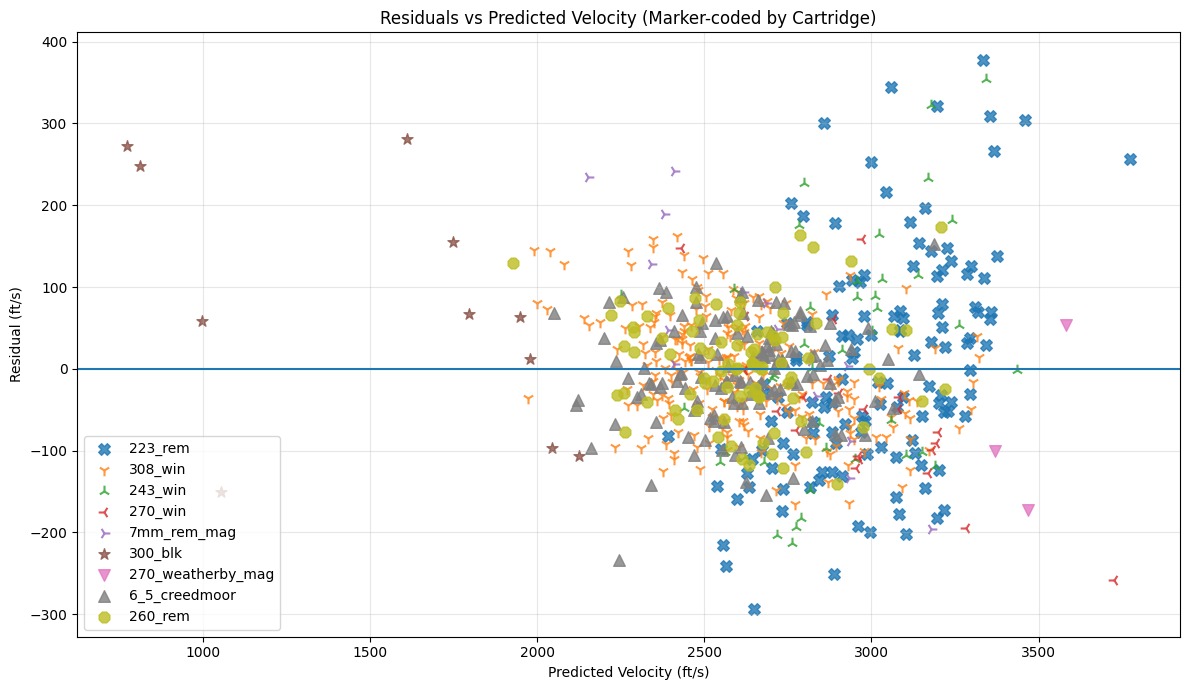

In [37]:
residuals = y_test.to_numpy() - preds

marker_map = {
    "223_rem": "X",
    "308_win": "1",
    "243_win": "2",
    "270_win": "3",
    "7mm_rem_mag": "4",
    "300_blk": "*",
    "270_weatherby_mag": "v",
    "6_5_creedmoor": "^",
    "260_rem": "8",
}

plt.figure(figsize=(12, 7))

for cartridge, marker in marker_map.items():
    mask = X_test["cartridge"] == cartridge
    plt.scatter(
        preds[mask],
        residuals[mask],
        marker=marker,
        s=70,
        alpha=0.8,
        label=cartridge
    )

plt.axhline(0,)
plt.xlabel("Predicted Velocity (ft/s)")
plt.ylabel("Residual (ft/s)")
plt.title("Residuals vs Predicted Velocity (Marker-coded by Cartridge)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation of results:
I tried adjusting the slopes of the offending cartridges by creating interactions with the charge weights.
- The .300blk cartridge's residual slope has apparently leveled out. It now shows a strong positive bias. I am interpreting this to believe the interaction corrected the slope issue but revealed an intercept mismatch that can be easily corrected in the next model iteration
- The .223rem's residual revealed:
  - Slope offset did not change
  - Structure opened up, suggesting that the added interaction loosened the model's forced compromise
  - The model was over-constrained before and now has more freedom but the correct interaction lies somewhere other than the charge weight. The next step for attempting to right the slope will be to change the interaction feature to burn_rate_index in lieu of charge_weight
